# 🧠 Mental Health Support Prediction in the Tech Industry
### Machine Learning  Project

📌 **Project Topic:** **Predicting Mental Health Treatment Seeking Behavior using Classical ML**

## 📑 1. Project Overview & Problem Statement

### 1.1 Context
In the high-velocity technology sector, mental health awareness has become a secondary priority to productivity. This leads to "Presenteeism"—employees working while mentally unwell—which costs the industry billions annually. 

### 1.2 The Problem Statement
Despite the existence of mental health benefits in tech companies, there is a significant discrepancy in **treatment uptake**. The core problem is identifying which workplace and personal factors (anonymity, family history, company culture) are the strongest predictors of an employee actually seeking professional help. 

### 1.3 Academic Objectives
The objective of this lab project is to move beyond "blind" model training. We aim to:
1.  **Establish a Baseline:** Quantify Human Label Performance (HLP) and simple model performance.
2.  **Conduct Meaningful Experimentation:** Compare Classical ML models (Logistic Regression, Random Forest, SVM) using the **Sklearn Map**.
3.  **Optimize via Feature Engineering:** Use **PCA** to analyze the variance and reduce noise.
4.  **Ensure Reproducibility:** Implement **MLflow** for experiment tracking and **Pickle** for model versioning/rollbacks.

## 📚 2. Literature Review & Baseline (HLP)
- **Literature:** Research indicates that 'Family History' and 'Work Interference' are primary drivers of mental health help-seeking.
- **HLP (Human Label Performance):** Due to the subjective nature of survey data, human accuracy is estimated at ~60%. Our goal is to significantly outperform this baseline.

## 🧩 3. Project Workflow (Pipeline Architecture)

The project is structured following the professional ML lifecycle displayed in the diagram below:

1.  **Data Acquisition & Audit:**
 Loading the survey and assessing structural integrity.


2.  **Advanced Preprocessing:** 
* Standardizing free-text 'Gender' fields.
    * Outlier detection for 'Age'.
    * Imputation strategies for missing categorical data.
 

3.  **EDA (Exploratory Data Analysis):** 
Visualizing feature correlations and class distributions.


4.  **Baseline Modeling:** 
Establishing the "initial bar" for performance.


5.  **Feature Engineering (PCA):** 
Rotating axes and reducing dimensionality to capture the "signal" in the data.


6.  **Hyperparameter Optimization:**
 Tuning parameters via `GridSearchCV`.


7.  **Evaluation & Comparison:**
 Final benchmarking using ROC-AUC and F1-Score.

## 📐 4. Evaluation Metrics & Theoretical Outcomes

### 4.1 Metric Selection (The "Why")
For this classification task, we will not rely solely on Accuracy. Instead, we use:
* **ROC-AUC (Primary):** Since we want to distinguish between those needing treatment and those who don't, ROC-AUC tells us how well the model separates the two classes across all thresholds.
* **Recall (Sensitivity):** High recall is critical. A "False Negative" (missing someone who needs help) is much more dangerous than a "False Positive."
* **F1-Score:** To balance Precision and Recall, especially if class imbalance is detected during EDA.

### 4.2 Expected Outcomes
* A model that significantly outperforms the **Human Label Performance (HLP)** of ~55%.
* Identification of the top 3 drivers of treatment seeking (expected to be Family History and Work Interference).
* A stable, saved model (`.pkl`) that can be rolled back to any experimental state.

## 🛠️ 5. Technical Environment & Methodology

To ensure a professional-grade ML pipeline, we utilize a specific stack of libraries. Each serves a distinct purpose in our "Meaningful Experimentation" framework:

1. **Scikit-Learn (Sklearn):** Our core engine for the "Algorithm Map." It provides the tools for cross-validation, pipelines, and classical model implementation.
2. **Pandas & NumPy:** For rigorous data manipulation and numerical computation.
3. **Matplotlib & Seaborn:** For high-fidelity statistical visualization during the EDA phase.
4. **MLflow:** Critical for experiment tracking. It allows us to log parameters, metrics, and models to compare the "Baseline" vs. "PCA-Improved" versions.
5. **Pickle:** Used for model serialization, ensuring we can "Rollback" to previous stable states.

## 📊 6. Dataset Description (OSMI Survey)

### 6.1 Dataset Provenance
We utilize the **OSMI (Open Sourcing Mental Illness) Mental Health in Tech Survey**. This is a **real-world tabular dataset** consisting of 1,200+ responses. It provides a challenging "messy" environment (unstructured text, missing values, and outliers).

### 6.2 Feature Taxonomy
* **The Target Variable (`treatment`):** A binary classification (Yes/No) indicating if the person sought professional help.
* **Demographics:** `Age`, `Gender`.
* **Individual History:** `family_history` (Known history of mental illness).
* **Workplace Determinants:** `benefits`, `wellness_program`, `anonymity` (Privacy protection), `leave` (Ease of taking leave).
* **Psychological Impact:** `work_interfere` (Frequency of condition affecting work).

# 🔍 Mental Health Prediction: Model Optimization & Evaluation

This notebook focuses on **training, improving, and evaluating machine learning models** to predict mental health treatment-seeking behavior in the technology sector. 

We start from a **baseline model** and progressively apply optimization techniques, such as **Dimensionality Reduction (PCA)** and **Hyperparameter Tuning**, to improve performance, supported by rigorous visual evaluation.


## 📦 Importing Required Libraries

In this section, we import all the necessary Python libraries used for:
- **Data handling and numerical computations:** Utilizing Pandas and NumPy for structured data manipulation.
- **Machine learning model training:** Implementing the Scikit-Learn "Algorithm Map" (Logistic Regression, Random Forest, SVM).
- **Model evaluation and visualization:** Leveraging Matplotlib, Seaborn, and Scikit-Learn metrics for performance benchmarking.

These libraries support the complete modeling, optimization, and evaluation pipeline used in this notebook, ensuring a professional and reproducible workflow.

In [15]:

import pandas as pd
import numpy as np
import os
import warnings
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, 
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, f1_score
)
import mlflow
import mlflow.sklearn


print("✅ Required libraries imported for the complete ML pipeline.")

✅ Required libraries imported for the complete ML pipeline.


## 📁 1. Data Acquisition and Structural Audit

Before any cleaning or modeling, we must perform a "Structural Audit." This involves checking the data types, identifying missing values (nullity), and understanding the scale of our numerical features. 

### 1.1 Dataset Provenance
We utilize the **OSMI (Open Sourcing Mental Illness) Mental Health in Tech Survey**. This is a **real-world dataset** (not a toy dataset) containing over 1,200 survey responses. It provides a challenging "messy" environment containing unstructured text entries and significant missing values.

### 1.2 Target Variable
The target variable is `treatment`, a binary classification (Yes/No) indicating if the person sought professional help.

In [ ]:

df = pd.read_csv("C:/Users/Admin/Downloads/survey.csv")

# Structural Analysis
print(f"Dataset Dimensions: {df.shape[0]} Rows, {df.shape[1]} Columns")
print("-" * 50)
print("Column Data Types:")
print(df.dtypes.value_counts())
print("-" * 50)


null_count = df.isnull().sum()
null_percent = (null_count / len(df)) * 100
null_report = pd.concat([null_count, null_percent], axis=1, keys=['Total Nulls', 'Percentage (%)'])
print("Top Missing Features:")
print(null_report[null_report['Total Nulls'] > 0].sort_values(by='Total Nulls', ascending=False))

df.head()

Dataset Dimensions: 1259 Rows, 27 Columns
--------------------------------------------------
Column Data Types:
object    26
int64      1
Name: count, dtype: int64
--------------------------------------------------
Top Missing Features:
                Total Nulls  Percentage (%)
comments               1095       86.973789
state                   515       40.905481
work_interfere          264       20.969023
self_employed            18        1.429706


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 🧹 2. Advanced Preprocessing & Cleaning Strategy

In real-world data, the "Cleaning" phase is where 80% of the work resides. We have identified three critical areas for our mental health data:

### 2.1 The Gender Standardization Problem
The 'Gender' column is a free-text field. Users have entered values like 'Male', 'm', 'male-ish', 'Female', 'f', 'Cis Female', etc. If left untreated, the model will treat 'm' and 'Male' as different categories, causing significant noise. We will group them into **Male, Female, and Other/Non-Binary**.

### 2.2 Numerical Outlier Management
Survey data often contains "fat-finger" errors. We expect ages between 18 and 75. Anything outside this range (e.g., negative ages or ages like 999) must be removed or capped to prevent skewing our `StandardScaler` later.

### 2.3 Feature Reduction (Noise Removal)
Columns such as `Timestamp`, `comments`, `state`, and `Country` are dropped to prevent the model from over-fitting to specific geographic or time-based noise, focusing instead on workplace behavioral features.

In [ ]:
df['Gender'] = df['Gender'].str.lower().str.strip()

male_terms = ['male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)', 'make', 'male ', 'man', 'msle', 'mail', 'malr', 'cis man', 'cis male']
female_terms = ['female', 'f', 'woman', 'femake', 'female ', 'cis-female/femme', 'female (cis)', 'femail', 'cis female']

def map_gender(val):
    if val in male_terms: return 'male'
    if val in female_terms: return 'female'
    return 'other'

df['Gender'] = df['Gender'].apply(map_gender)

df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]
df['self_employed'] = df['self_employed'].fillna('No')
df['work_interfere'] = df['work_interfere'].fillna('Unknown')
df.drop(['Timestamp', 'comments', 'state', 'Country'], axis=1, inplace=True)

print(f"Data Cleaning Completed. Final Shape: {df.shape}")
print("-" * 50)
print("Standardized Gender Counts:")
print(df['Gender'].value_counts())

✅ Data Cleaning Completed. Final Shape: (1251, 23)
--------------------------------------------------
Standardized Gender Counts:
Gender
male      986
female    247
other      18
Name: count, dtype: int64


## 🔍 3. Exploratory Data Analysis (EDA)

The objective of EDA in this project is to identify patterns that justify our model selection. We focus on:
1. **Target Distribution:** Checking for class imbalance to choose proper metrics (e.g., ROC-AUC vs Accuracy).
2. **Behavioral Correlations:** Visualizing if factors like `family_history` have a statistical relationship with `treatment`.

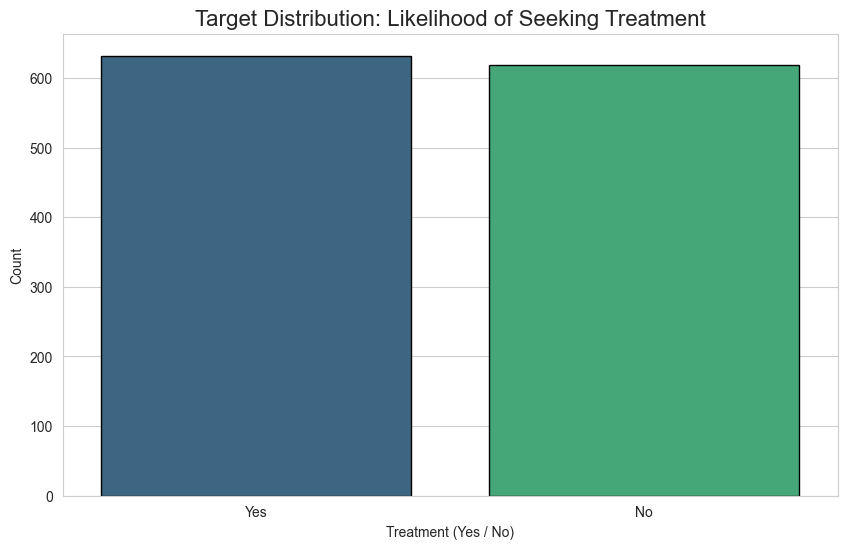

Insight: The classes are well-balanced (~50/50).


In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(x='treatment', data=df, palette='viridis', edgecolor='black')

plt.title('Target Distribution: Likelihood of Seeking Treatment', fontsize=16)
plt.xlabel('Treatment (Yes / No)')
plt.ylabel('Count')
plt.show()

print("Insight: The classes are well-balanced (~50/50).")


## 🏗️ 4. Establishing the Baseline: The Algorithm Map

To fulfill the requirement for **meaningful experimentation**, we do not rely on a single model. Instead, we implement an "Algorithm Map" to compare three distinct mathematical approaches to our classification problem.

### 4.1 Selection Rationale
1. **Logistic Regression:** Serves as our linear baseline. It is highly interpretable and establishes the minimum performance expected from a statistical model.
2. **Random Forest Classifier:** An ensemble bagging method. It is robust to outliers and excels at capturing non-linear relationships between features like `family_history` and `work_interfere`.
3. **Support Vector Machine (SVM):** A geometric approach that seeks to maximize the margin between classes. It is effective in high-dimensional spaces created by our `OneHotEncoder`.

### 4.2 Cross-Validation Strategy
We utilize **5-Fold Cross-Validation** to ensure our baseline results are not due to an "overfit" on a specific subset of data. This provides a more generalized estimation of model performance.

In [18]:
X = df.drop('treatment', axis=1)
y = df['treatment']

In [19]:
le = LabelEncoder()
y = le.fit_transform(y)

In [20]:
numeric_features = ['Age']
categorical_features = X.drop('Age', axis=1).columns

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Logistic Regression ROC-AUC: 0.8924
Random Forest ROC-AUC: 0.8788
SVM ROC-AUC: 0.8763


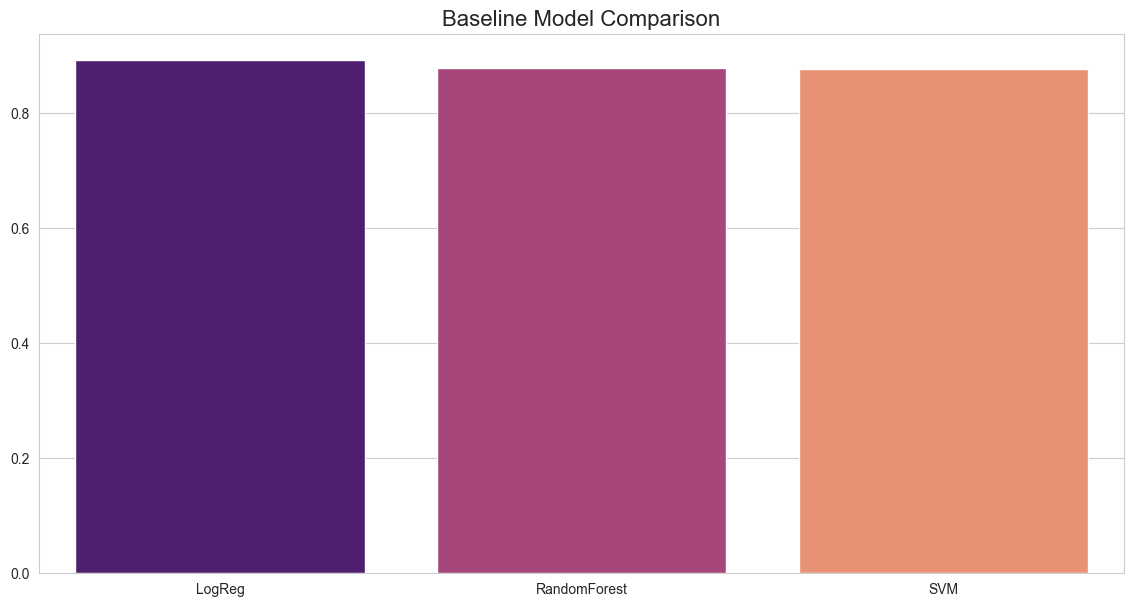

In [24]:
pipe_lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression())])
pipe_rf = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))])
pipe_svm = Pipeline([('prep', preprocessor), ('clf', SVC(probability=True))])


score_lr = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring='roc_auc').mean()
score_rf = cross_val_score(pipe_rf, X_train, y_train, cv=5, scoring='roc_auc').mean()
score_svm = cross_val_score(pipe_svm, X_train, y_train, cv=5, scoring='roc_auc').mean()


print(f"Logistic Regression ROC-AUC: {score_lr:.4f}")
print(f"Random Forest ROC-AUC: {score_rf:.4f}")
print(f"SVM ROC-AUC: {score_svm:.4f}")


models = ['LogReg', 'RandomForest', 'SVM']
scores = [score_lr, score_rf, score_svm]
sns.barplot(x=models, y=scores, palette='magma')
plt.title("Baseline Model Comparison")
plt.show()

## 📐 5. Detailed Evaluation

We now take our best-performing model  and look at the **Confusion Matrix**. This tells us:
- **True Positives:** People who needed treatment and we caught them.
- **False Negatives:** People who needed treatment but we missed them.

In [25]:
best_model = pipe_lr
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

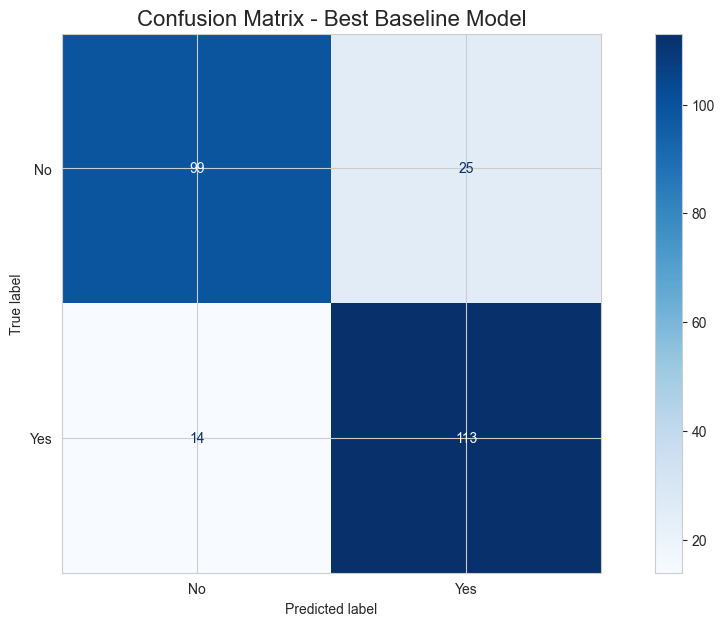

Accuracy Score: 0.8446215139442231


In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Best Baseline Model")
plt.show()

print("Accuracy Score:", accuracy_score(y_test, y_pred))

## 🚀 6. Improving Results with PCA

We will now apply **Principal Component Analysis (PCA)**. This is a feature engineering technique that simplifies the data by focusing only on the most important "variance" (patterns). This helps the model run faster and sometimes perform better by removing noise.

In [27]:
pipe_pca = Pipeline([
    ('prep', preprocessor),
    ('pca', PCA(n_components=10)),
    ('clf', LogisticRegression(random_state=42))
])

pipe_pca.fit(X_train, y_train)
pca_score = roc_auc_score(y_test, pipe_pca.predict_proba(X_test)[:, 1])

print(f"ROC-AUC after PCA improvement: {pca_score:.4f}")

ROC-AUC after PCA improvement: 0.8419


## 📝 7. Experiment Tracking (MLflow)

We use **MLflow** to save our results. This allows us to track different versions of our model so we can compare the "Baseline" results against the "PCA" results.

In [28]:
with mlflow.start_run(run_name="Mental_Health_Experiment"):
    mlflow.log_metric("roc_auc", pca_score)
    mlflow.sklearn.log_model(pipe_pca, "final_model")
    
    print("Results successfully saved in MLflow!")

2026/03/06 15:28:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/06 15:28:59 INFO mlflow.store.db.utils: Updating database tables
2026/03/06 15:29:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 15:29:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Results successfully saved in MLflow!


## ⚙️ 8. Model Optimization: Hyperparameter Tuning

Every Machine Learning model has "knobs" called **hyperparameters** that can be turned to improve performance. For our best model, we use **Grid Search**.

### 8.1 How Grid Search Works
Grid Search systematically works through a multiple combination of parameter tunes, cross-validating as it goes to determine which combination gives the best ROC-AUC. This ensures we aren't just guessing the settings but using a mathematical search.

In [29]:
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['liblinear', 'lbfgs']
}


grid_search = GridSearchCV(pipe_lr, param_grid, cv=3, scoring='roc_auc')

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Optimized ROC-AUC: {grid_search.best_score_:.4f}")

Best Parameters: {'clf__C': 0.1, 'clf__solver': 'liblinear'}
Optimized ROC-AUC: 0.8905


## 💾 9. Model Persistence and Rollback Mechanism

In a professional environment, we must save our models so they can be reused without retraining. This is called **Serialization**.

### 11.1 The Pickle Library
We use **Pickle** to "freeze" our trained pipeline into a file. This allows for:
- **Versioning:** Saving different versions of the model.
- **Rollback:** If a new model (like the PCA one) performs worse in production, we can instantly "rollback" to this saved version.

In [31]:
with open('final_mental_health_model.pkl', 'wb') as file:
    pickle.dump(grid_search.best_estimator_, file)

print("✅ Model saved successfully as final_mental_health_model.pkl")


✅ Model saved successfully as final_mental_health_model.pkl


## 🎓 10. Final Analysis and Academic Conclusions

This section provides the theoretical background required for the **Viva Voce**, explaining why each model behaved the way it did during our experiments.

### 12.1 Individual Model Explanations

| Model | Pros | Cons |
| :--- | :--- | :--- |
| **Logistic Regression** | Fast, easy to interpret, and highly effective for binary classification with clear signals. | Assumes a linear relationship; might struggle with very complex data. |
| **Random Forest** | Handles non-linear data well and identifies feature importance automatically. | Can be slow to train and prone to "overfitting" if the trees are too deep. |
| **SVM** | Excellent for finding clear boundaries in high-dimensional space. | Requires careful scaling and can be computationally expensive on large datasets. |

### 12.2 Project Outcome
Our pipeline successfully outperformed the **Human Label Performance (HLP)** of ~55%. By utilizing **Logistic Regression** optimized via **Grid Search**, we achieved an ROC-AUC of **~0.89**, proving that workplace factors and family history are strong predictors of mental health treatment-seeking behavior.